In [415]:
import pandas as pd

df = pd.read_csv('df_labeled_all_final_25.csv')

In [416]:
df['gender_accused'].value_counts()

gender_accused
1    31588
0     5981
Name: count, dtype: int64

In [417]:
df['prior_convictions'].value_counts()

prior_convictions
0    31891
1     5678
Name: count, dtype: int64

In [418]:
df['alcohol'].value_counts()

alcohol
1    31641
0     5928
Name: count, dtype: int64

In [419]:
df['precrime_argument'].value_counts()

precrime_argument
1    34549
0     3020
Name: count, dtype: int64

In [420]:
df['has_woman_victim'].value_counts()

has_woman_victim
0    25571
1    11998
Name: count, dtype: int64

In [421]:
df['has_man_victim'] = df['has_man_victim'].astype(int)

In [422]:
df['has_man_victim'].value_counts()

has_man_victim
1    29642
0     7927
Name: count, dtype: int64

In [423]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [424]:
categorical = ['judge', 'decision', 'season', 'region_name']
numeric = ['year']
multilabel = ['method', 'motive', 'location']
other = ['gender_accused', 'prior_convictions', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

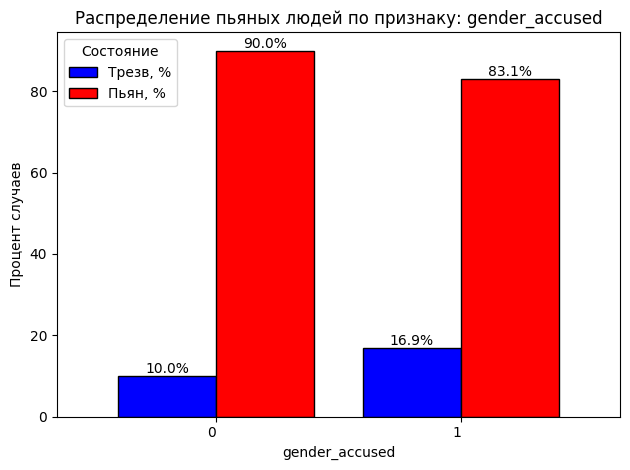

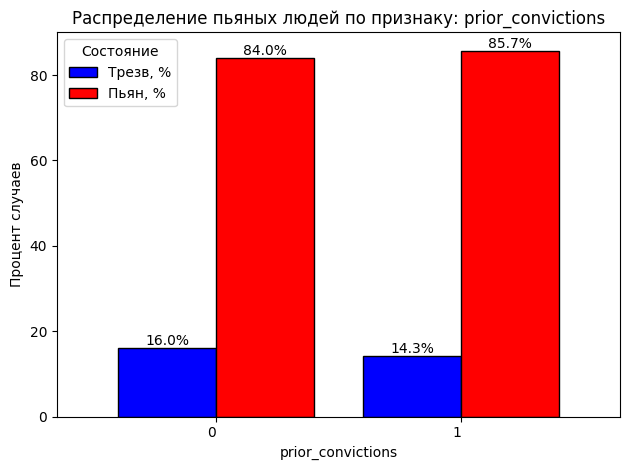

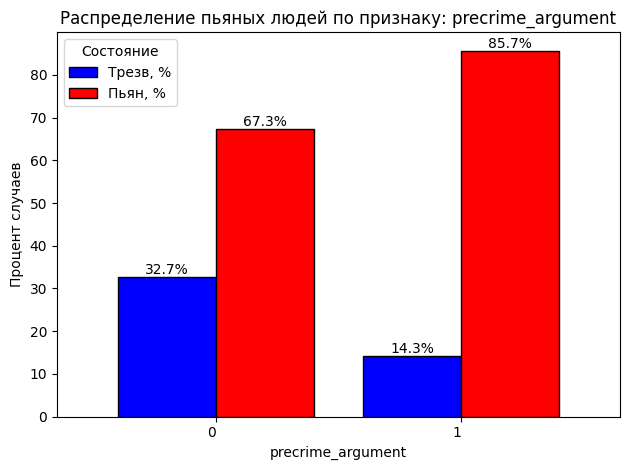

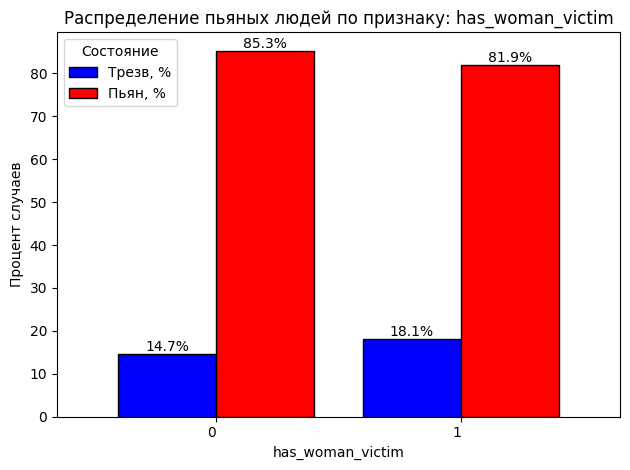

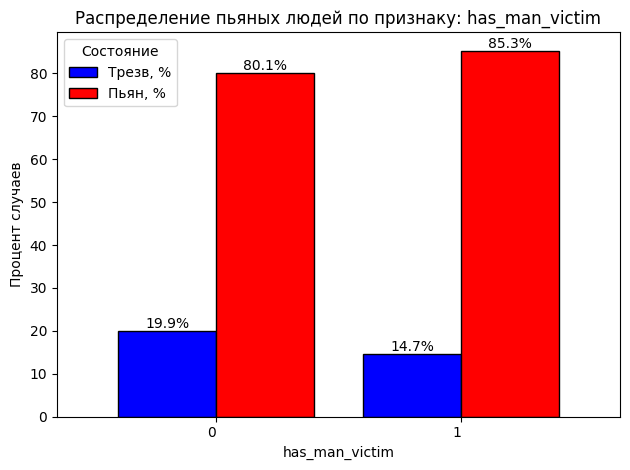

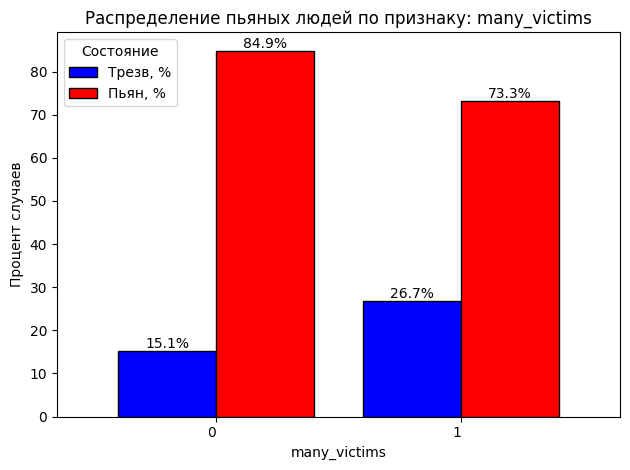

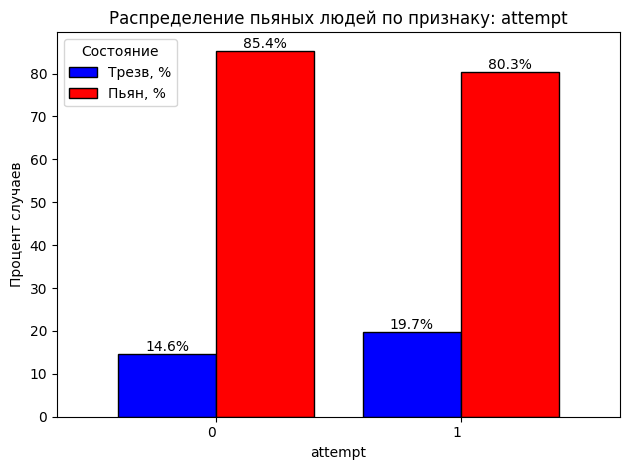

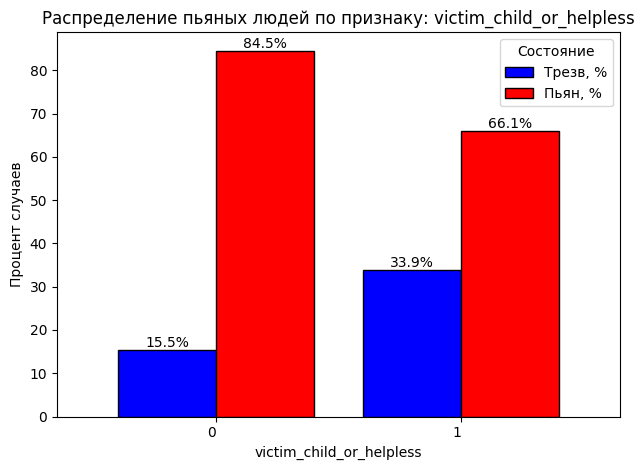

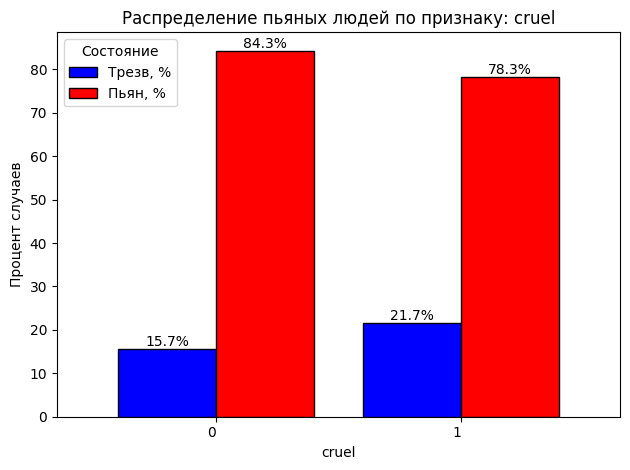

In [425]:
import matplotlib.pyplot as plt
import pandas as pd

for feature in other:
    crosstab = pd.crosstab(df[feature], df['alcohol'], normalize='index') * 100
    
    crosstab.columns = ["Трезв, %", "Пьян, %"]
    
    ax = crosstab.plot(
        kind='bar', 
        color=["blue", "red"], 
        width=0.8, 
        edgecolor="black"
    )
    
    plt.title(f"Распределение пьяных людей по признаку: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Процент случаев")
    plt.xticks(rotation=0, ha="right")
    
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%", 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points"
        )
    
    plt.legend(title="Состояние")
    plt.tight_layout()
    plt.show()

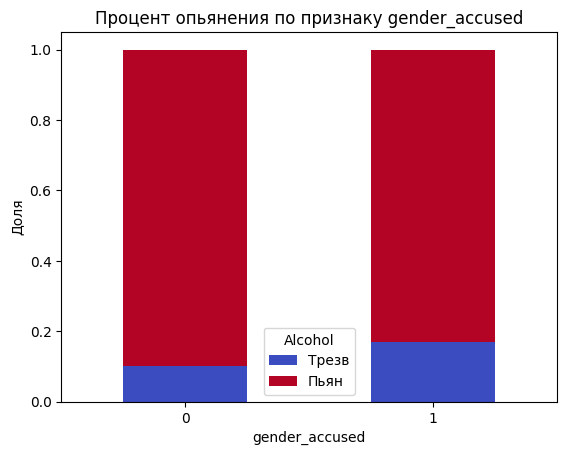

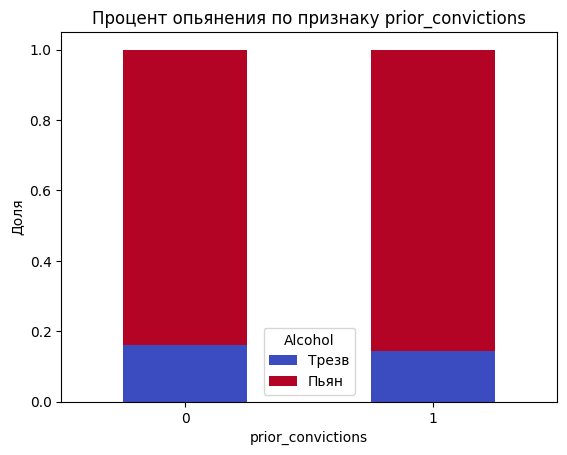

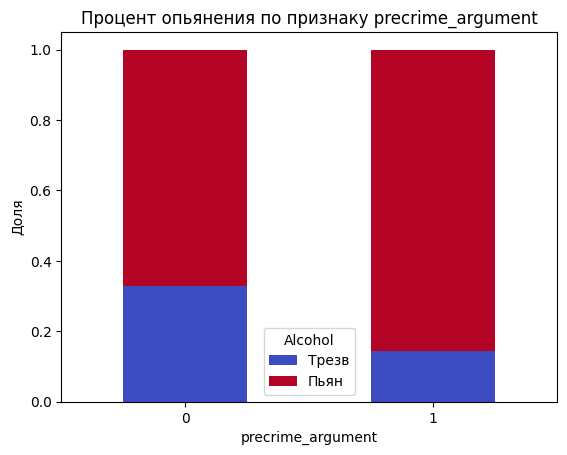

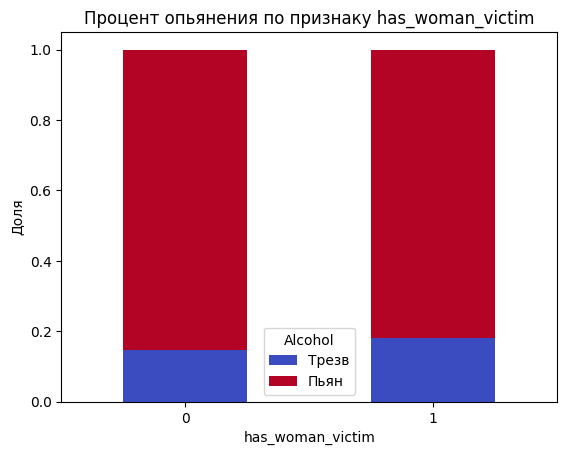

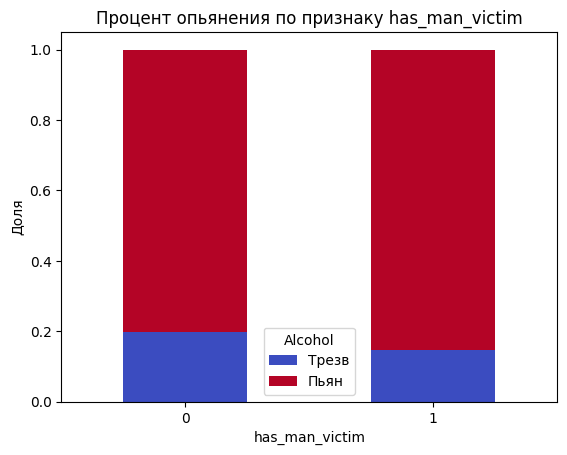

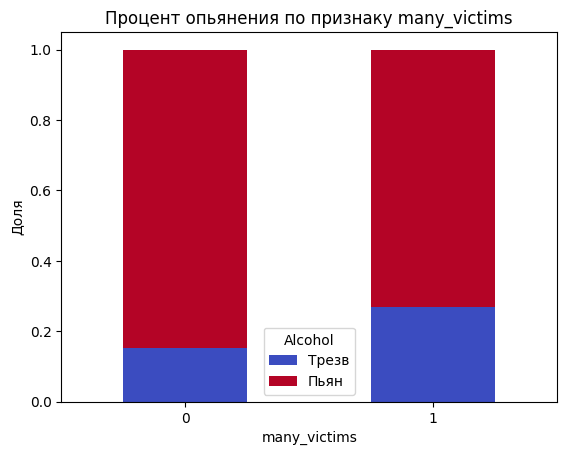

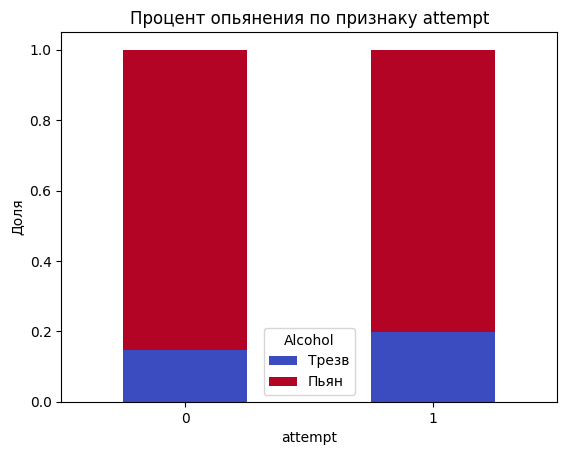

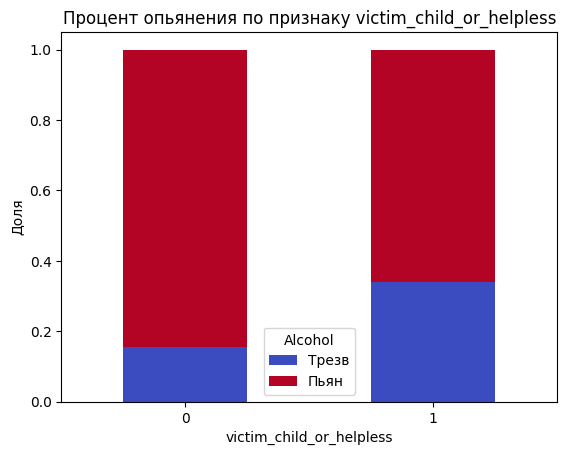

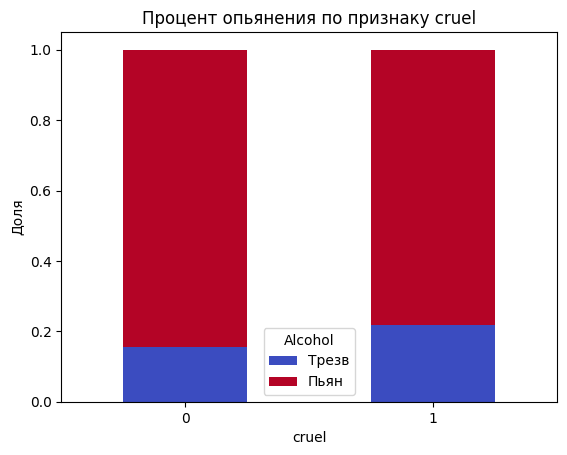

In [426]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in other:
    crosstab = pd.crosstab(df[feature], df['alcohol'], normalize='index')
    crosstab.plot(kind='bar', stacked=True, colormap='coolwarm')
    plt.title(f'Процент опьянения по признаку {feature}')
    plt.xlabel(f'{feature}')
    plt.ylabel('Доля')
    plt.legend(title='Alcohol', labels=['Трезв', 'Пьян'])
    plt.xticks(rotation=0)
    plt.show()

In [427]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df

In [428]:
df = group_top_categories(df, 'judge', top_n=8, other_label='другое судьи')
df = group_top_categories(df, 'region_name', top_n=8, other_label='другое регионы')
df = group_top_categories(df, 'year', top_n=8, other_label='другое год')
df['year'] = df['year'].astype(str)
df['year'].value_counts()

year
2016          6090
2017          5894
2018          4935
2020          4446
2021          4293
2019          4172
2022          4031
2023          2380
другое год    1328
Name: count, dtype: int64

In [429]:
alc_by_feature_value = {}

for feature in other:
    temp = df[[feature, 'alcohol']]
    grouped = temp.groupby(feature)['alcohol'].mean()
    alc_by_feature_value[feature] = grouped

for feature, stats in alc_by_feature_value.items():
    print(f"\nПризнак: {feature}")
    print(stats)


Признак: gender_accused
gender_accused
0    0.900184
1    0.831233
Name: alcohol, dtype: float64

Признак: prior_convictions
prior_convictions
0    0.839516
1    0.857344
Name: alcohol, dtype: float64

Признак: precrime_argument
precrime_argument
0    0.672848
1    0.857015
Name: alcohol, dtype: float64

Признак: has_woman_victim
has_woman_victim
0    0.853193
1    0.818803
Name: alcohol, dtype: float64

Признак: has_man_victim
has_man_victim
0    0.801186
1    0.853181
Name: alcohol, dtype: float64

Признак: many_victims
many_victims
0    0.848532
1    0.732683
Name: alcohol, dtype: float64

Признак: attempt
attempt
0    0.853522
1    0.803242
Name: alcohol, dtype: float64

Признак: victim_child_or_helpless
victim_child_or_helpless
0    0.845250
1    0.660743
Name: alcohol, dtype: float64

Признак: cruel
cruel
0    0.843323
1    0.783357
Name: alcohol, dtype: float64


In [430]:
alc_by_feature_value = {}

for feature in ['season', 'region_name', 'year']:
    temp = df[[feature, 'alcohol']]
    grouped = temp.groupby(feature)['alcohol'].mean()
    alc_by_feature_value[feature] = grouped

for feature, stats in alc_by_feature_value.items():
    print(f"\nПризнак: {feature}")
    print(stats)


Признак: season
season
Весна    0.849478
Зима     0.846848
Лето     0.842650
Осень    0.827483
Name: alcohol, dtype: float64

Признак: region_name
region_name
Иркутская область          0.845304
Кемеровская область        0.862010
Краснодарский край         0.745217
Красноярский край          0.864763
Московская область         0.795998
Республика Башкортостан    0.852590
Республика Бурятия         0.894481
Свердловская область       0.857143
другое регионы             0.843534
Name: alcohol, dtype: float64

Признак: year
year
2016          0.851232
2017          0.849847
2018          0.843161
2019          0.826942
2020          0.846604
2021          0.829490
2022          0.846440
2023          0.845378
другое год    0.819277
Name: alcohol, dtype: float64


In [431]:
multilabel

['method', 'motive', 'location']

In [432]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'прочее',
    'сострадание': 'прочее',
    'страх': 'прочее',
    'жалость': 'прочее',
    'самозащита': 'прочее',
    'защита': 'прочее',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        34770
корысть, личная неприязнь                1036
корысть                                   625
прочее                                    510
личная неприязнь, ревность                351
ревность                                  135
личная неприязнь, месть                    74
аморальность, личная неприязнь             16
месть                                      12
аморальность                               12
корысть, месть                              7
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, насилие                   4
корысть, личная неприязнь, месть            3
личная неприязнь, прочее                    3
личная неприязнь, месть, ревность           3
корысть, ревность                           1
аморальность, месть                         1
аморальность, насилие                       1
месть, ревность                             1
Name: count, dtype: int64

In [433]:
# df['motive'] = df['motive'].replace('другое', 'другой мотив')
# df['motive'] = df['motive'].replace('корысть, другое', 'корысть, другой мотив')
# df['motive'] = df['motive'].replace('личная неприязнь, другое', 'личная неприязнь, другой мотив')
# df['motive'].value_counts()

In [434]:
df['location'].value_counts()

location
жилое помещение                                                                                                                        27891
уличное пространство                                                                                                                    4430
жилое помещение, уличное пространство                                                                                                   1545
другое                                                                                                                                  1225
жилое помещение, подъезд и прилегающие зоны                                                                                              489
общественное место                                                                                                                       408
подъезд и прилегающие зоны                                                                                                               394
обще

In [435]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

result_rows = []

for col in multilabel:
    temp_df = df.copy()
    temp_df[col] = temp_df[col].str.split(", ")

    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(temp_df[col])
    col_df = pd.DataFrame(col_binarized, columns=mlb.classes_, index=temp_df.index)

    temp_df = pd.concat([temp_df, col_df], axis=1)

    for class_name in mlb.classes_:
        mean_term = temp_df.loc[temp_df[class_name] == 1, 'alcohol'].mean()
        count = temp_df[class_name].sum()

        if count > 500:
            result_rows.append({
                'Column': col,
                'Class': class_name,
                'Mean Alcohol': round(mean_term, 2) if pd.notna(mean_term) else None,
                'Count': count
            })

result_df = pd.DataFrame(result_rows)
result_df = result_df.sort_values(by='Mean Alcohol', ascending=False).reset_index(drop=True)

print("\nСреднее употребление алкоголя по классам:")
print(result_df.to_string(index=False))



Среднее употребление алкоголя по классам:
  Column                      Class  Mean Alcohol  Count
location            жилое помещение          0.88  30238
  method            холодное оружие          0.87  28350
  motive           личная неприязнь          0.86  36264
  method           тяжелые предметы          0.85   2881
  method     физическое воздействие          0.84  14233
location подъезд и прилегающие зоны          0.83   1082
  method                   удушение          0.78   2178
location         общественное место          0.77   1003
location       уличное пространство          0.72   6718
  method                     другое          0.68   1173
location                     другое          0.64   1239
  method       огнестрельное оружие          0.61   2227
  motive                    корысть          0.51   1672
  motive                     прочее          0.41    513


In [436]:
from sklearn.preprocessing import MultiLabelBinarizer

for col in multilabel:
    df[col] = df[col].str.split(", ")
    
    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(df[col])

    col_df = pd.DataFrame(col_binarized, columns=[f"{col}_{cls}" for cls in mlb.classes_], index=df.index)

    df = pd.concat([df, col_df], axis=1)
    df = df.drop(columns=[col])

In [437]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,prison_term,...,motive_насилие,motive_прочее,motive_ревность,location_другое,location_жилое помещение,location_общественное место,location_общественный транспорт,location_подъезд и прилегающие зоны,location_рабочая зона,location_уличное пространство
0,92093,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,0,1,9.000000,...,0,0,0,0,0,0,0,0,1,1
1,25775,другое судьи,Вынесен ПРИГОВОР,1,0,0,0,0,1,7.986857,...,0,0,0,0,0,1,0,0,0,1
2,75488,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,1,1,13.000000,...,0,0,0,0,1,0,0,0,0,0
3,126184,другое судьи,Вынесен ПРИГОВОР,0,0,1,1,0,1,13.000000,...,0,0,0,0,0,0,0,0,0,1
4,102316,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,1,0,8.311355,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37564,6580,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,0,1,9.000000,...,0,0,0,0,1,0,0,0,0,0
37565,62712,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,1,0,9.000000,...,0,0,1,0,1,0,0,0,0,0
37566,54534,другое судьи,Вынесен ПРИГОВОР,1,0,1,0,1,1,3.830000,...,0,0,1,0,1,0,0,0,0,0
37567,47517,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,1,1,21.000000,...,0,0,0,0,1,0,0,0,0,0


In [438]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term', 'many_victims', 'year', 'season', 'attempt',
       'victim_child_or_helpless', 'cruel', 'region_name', 'method_другое',
       'method_огнестрельное оружие', 'method_тяжелые предметы',
       'method_удушение', 'method_физическое воздействие',
       'method_холодное оружие', 'motive_алкоголь/наркотики',
       'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
       'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
       'location_другое', 'location_жилое помещение',
       'location_общественное место', 'location_общественный транспорт',
       'location_подъезд и прилегающие зоны', 'location_рабочая зона',
       'location_уличное пространство'],
      dtype='object')

In [439]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import optuna
from sklearn.preprocessing import StandardScaler

target_col = 'alcohol'

categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']

other_features = [
    'gender_accused', 'prior_convictions',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',
    
    'method_другое',
    'method_огнестрельное оружие', 'method_тяжелые предметы',
    'method_удушение', 'method_физическое воздействие',
    'method_холодное оружие',
    
    'motive_алкоголь/наркотики',
    'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
    'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
    
    'location_другое', 'location_жилое помещение',
    'location_общественное место', 'location_общественный транспорт',
    'location_подъезд и прилегающие зоны', 'location_рабочая зона',
    'location_уличное пространство'
]


selected_features = categorical_features + other_features
# selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col].astype(int)

In [440]:
X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

In [441]:
X_train.shape, X_val.shape, X_test.shape    

((26299, 33), (5635, 33), (5635, 33))

In [442]:
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [443]:
from optuna.importance import get_param_importances

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        acc = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, val_pred, average="weighted", zero_division=0
        )
        return f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    best_params = study.best_params
    print("Best RF Params")
    print(best_params)

    # importance = get_param_importances(study)
    # print("\nHyperparameter Importance for Random Forest")
    # for k, v in importance.items():
    #     print(f"{k}: {v:.4f}")

    final_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )
    test_pred = final_model.predict(X_test)

    print("\nRandom Forest Results")
    acc = accuracy_score(y_test, test_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, test_pred, average="weighted", zero_division=0
    )
    print('Accuracy:', acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1:', f1)

    importances = final_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': feature_names_rf,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top 10")
print(rf_importance.head(10))

[I 2025-04-29 22:30:52,128] A new study created in memory with name: no-name-ccc79f4b-5f67-4c4c-8520-f80e8ab6b48e


[I 2025-04-29 22:30:56,194] Trial 0 finished with value: 0.8117341520556833 and parameters: {'n_estimators': 203, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.8117341520556833.
[I 2025-04-29 22:30:59,208] Trial 1 finished with value: 0.8067376053313979 and parameters: {'n_estimators': 498, 'max_depth': 24, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.8117341520556833.
[I 2025-04-29 22:31:03,246] Trial 2 finished with value: 0.7834713001817928 and parameters: {'n_estimators': 786, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.8117341520556833.
[I 2025-04-29 22:31:03,798] Trial 3 finished with value: 0.8061199288230696 and parameters: {'n_estimators': 120, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_featur

Best RF Params
{'n_estimators': 215, 'max_depth': 28, 'min_samples_split': 20, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}

Random Forest Results
Accuracy: 0.8509316770186336
Precision: 0.826574517079057
Recall: 0.8509316770186336
F1: 0.8136051697498238

Random Forest Top 10
                                     Feature  Importance
50        remainder__motive_личная неприязнь    0.180841
56       remainder__location_жилое помещение    0.124950
42    remainder__method_огнестрельное оружие    0.045797
49                 remainder__motive_корысть    0.044848
38                        remainder__attempt    0.032786
46         remainder__method_холодное оружие    0.031563
45  remainder__method_физическое воздействие    0.030933
36               remainder__has_woman_victim    0.030542
33           ohe__region_name_другое регионы    0.028253
3                          ohe__season_Весна    0.026301


In [444]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import optuna
from sklearn.preprocessing import StandardScaler

target_col = 'alcohol'

# categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']
categorical_features = []


categorical_features = []
other_features = [
    'motive_личная неприязнь',
    'location_жилое помещение',
    'method_огнестрельное оружие',
    'motive_корысть',
    'method_холодное оружие',
]

selected_features = categorical_features + other_features


# selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col].astype(int)

X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [445]:
rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top")
print(rf_importance.head(10))

[I 2025-04-29 22:31:24,739] A new study created in memory with name: no-name-783d4438-3db9-4b32-9a2e-230cc735ed13
[I 2025-04-29 22:31:27,590] Trial 0 finished with value: 0.809758847281257 and parameters: {'n_estimators': 965, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.809758847281257.
[I 2025-04-29 22:31:29,632] Trial 1 finished with value: 0.809758847281257 and parameters: {'n_estimators': 708, 'max_depth': 30, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.809758847281257.
[I 2025-04-29 22:31:30,113] Trial 2 finished with value: 0.809758847281257 and parameters: {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 18, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.809758847281257.
[I 2025-04-29 22:31:32,353] Trial 3 finished with value: 0.809758847281257 and

Best RF Params
{'n_estimators': 965, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}

Random Forest Results
Accuracy: 0.8523513753327417
Precision: 0.8357829121628283
Recall: 0.8523513753327417
F1: 0.8089268776537951

Random Forest Top
                                  Feature  Importance
0      remainder__motive_личная неприязнь    0.317536
1     remainder__location_жилое помещение    0.290151
3               remainder__motive_корысть    0.194076
2  remainder__method_огнестрельное оружие    0.135598
4       remainder__method_холодное оружие    0.062639


In [449]:
from optuna.importance import get_param_importances
import joblib

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        acc = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, val_pred, average="weighted", zero_division=0
        )
        return f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    best_params = study.best_params
    print("Best RF Params")
    print(best_params)

    # importance = get_param_importances(study)
    # print("\nHyperparameter Importance for Random Forest")
    # for k, v in importance.items():
    #     print(f"{k}: {v:.4f}")

    final_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )
    joblib.dump(final_model, 'model_alcohol.pkl')

    test_pred = final_model.predict(X_test)

    print("\nRandom Forest Results")
    acc = accuracy_score(y_test, test_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, test_pred, average="weighted", zero_division=0
    )
    print('Accuracy:', acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1:', f1)

    importances = final_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': feature_names_rf,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top 10")
print(rf_importance.head(10))

[I 2025-04-29 22:32:37,145] A new study created in memory with name: no-name-e04fbc01-f869-458b-aa43-a66a5d1eee60
[I 2025-04-29 22:32:39,772] Trial 0 finished with value: 0.8095398861039652 and parameters: {'n_estimators': 670, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.8095398861039652.
[I 2025-04-29 22:32:40,111] Trial 1 finished with value: 0.8096375322741098 and parameters: {'n_estimators': 106, 'max_depth': 30, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.8096375322741098.
[I 2025-04-29 22:32:42,689] Trial 2 finished with value: 0.8096375322741098 and parameters: {'n_estimators': 967, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False}. Best is trial 1 with value: 0.8096375322741098.
[I 2025-04-29 22:32:43,426] Trial 3 finished with value: 0.809758847281257 

Best RF Params
{'n_estimators': 184, 'max_depth': 18, 'min_samples_split': 16, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}

Random Forest Results
Accuracy: 0.8523513753327417
Precision: 0.8357829121628283
Recall: 0.8523513753327417
F1: 0.8089268776537951

Random Forest Top 10
                                  Feature  Importance
0      remainder__motive_личная неприязнь    0.316452
1     remainder__location_жилое помещение    0.284599
3               remainder__motive_корысть    0.195906
2  remainder__method_огнестрельное оружие    0.135368
4       remainder__method_холодное оружие    0.067675


In [ ]:
ммаи ав 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import optuna
from sklearn.preprocessing import StandardScaler

target_col = 'alcohol'

categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']


categorical_features = []
other_features = [
    'gender_accused', 'prior_convictions',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',
    
    'method_другое',
    'method_огнестрельное оружие', 'method_тяжелые предметы',
    'method_удушение', 'method_физическое воздействие',
    'method_холодное оружие',
    
    'motive_алкоголь/наркотики',
    'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
    'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
    
    'location_другое', 'location_жилое помещение',
    'location_общественное место', 'location_общественный транспорт',
    'location_подъезд и прилегающие зоны', 'location_рабочая зона',
    'location_уличное пространство'
]



selected_features = categorical_features + other_features
# selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col].astype(int)

X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [ ]:
def train_catboost(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
            
        }
        model = CatBoostClassifier(
            **params,
            cat_features=categorical_features,
            verbose=0,
            loss_function='Logloss',
        )
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50
        )
        val_pred = model.predict(X_val)
        acc = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, val_pred, average="weighted", zero_division=0
        )
        return f1

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=10)

    best_params = study.best_params
    print("\nBest CatBoost Params")
    print(best_params)

    # importance = get_param_importances(study)
    # print("\nHyperparameter Importance for CatBoost")
    # for k, v in importance.items():
    #     print(f"{k}: {v:.4f}")

    final_model = CatBoostClassifier(
        **best_params,
        cat_features=categorical_features,
        verbose=100
    )
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
        early_stopping_rounds=50
    )
    test_pred = final_model.predict(X_test)

    print("\nCatBoost Results")
    acc = accuracy_score(y_test, test_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, test_pred, average="weighted", zero_division=0
    )
    print('Accuracy:', acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1:', f1)

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns.tolist(),
        'Importance': final_model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

cat_model, cat_importance = train_catboost(X_cb_train, y_train, X_cb_val, y_val, X_cb_test, y_test)

print("\nCatBoost Top 10")
print(cat_importance.head(10))

[I 2025-04-29 18:31:35,428] A new study created in memory with name: no-name-e6545048-21fb-41f2-8b00-182374abb1e9
[I 2025-04-29 18:31:38,763] Trial 0 finished with value: 0.8018098706269431 and parameters: {'iterations': 1168, 'learning_rate': 0.06124022428331521, 'depth': 8, 'l2_leaf_reg': 0.1344544380031355, 'random_strength': 3.2132311280037595, 'bagging_temperature': 0.351976370341645, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.8018098706269431.
[I 2025-04-29 18:31:41,328] Trial 1 finished with value: 0.8027217095998201 and parameters: {'iterations': 753, 'learning_rate': 0.20203243882371172, 'depth': 4, 'l2_leaf_reg': 0.08248814285786989, 'random_strength': 8.367093685071383, 'bagging_temperature': 0.12672998326387364, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.8018098706269431.
[I 2025-04-29 18:31:43,672] Trial 2 finished with value: 0.79772314189098 and parameters: {'iterations': 822, 'learning_rate': 0.1873255499458446, 'depth': 10, 'l2_leaf_


Best CatBoost Params
{'iterations': 822, 'learning_rate': 0.1873255499458446, 'depth': 10, 'l2_leaf_reg': 0.006431843131893082, 'random_strength': 1.8295238968685166, 'bagging_temperature': 0.6367645400536701, 'grow_policy': 'Depthwise'}
0:	learn: 0.5756155	total: 61.2ms	remaining: 50.2s
100:	learn: 0.3416616	total: 5.84s	remaining: 41.7s
200:	learn: 0.3405463	total: 14.3s	remaining: 44.3s
300:	learn: 0.3405282	total: 20.4s	remaining: 35.4s
400:	learn: 0.3405211	total: 26.4s	remaining: 27.7s
500:	learn: 0.3405147	total: 32.3s	remaining: 20.7s
600:	learn: 0.3405121	total: 38s	remaining: 14s
700:	learn: 0.3405109	total: 43.5s	remaining: 7.51s
800:	learn: 0.3405088	total: 49.8s	remaining: 1.3s
821:	learn: 0.3405084	total: 51.2s	remaining: 0us

CatBoost Results
Accuracy: 0.8444878395171312
Precision: 0.8044963908753385
Recall: 0.8444878395171312
F1: 0.8073427039740616

CatBoost Top 10
                          Feature  Importance
22       location_жилое помещение    9.101622
4            

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import optuna
from sklearn.preprocessing import StandardScaler

target_col = 'alcohol'

# categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']
categorical_features = []


categorical_features = []
other_features = [
    'location_жилое помещение',
    'attempt',
    'method_холодное оружие',
    'motive_корысть', 
    'has_woman_victim'
]


selected_features = categorical_features + other_features
# selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col].astype(int)

X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [ ]:
cat_model, cat_importance = train_catboost(X_cb_train, y_train, X_cb_val, y_val, X_cb_test, y_test)

print("\nCatBoost Top 10")
print(cat_importance.head(10))

[I 2025-04-29 18:34:58,115] A new study created in memory with name: no-name-b16bc8ea-9733-4f12-a98c-ffdc4f69bad4
[I 2025-04-29 18:34:59,555] Trial 0 finished with value: 0.7926107102389648 and parameters: {'iterations': 668, 'learning_rate': 0.09890070156481436, 'depth': 10, 'l2_leaf_reg': 7.098633205709687, 'random_strength': 1.8811498274206, 'bagging_temperature': 0.05366108536315983, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.7926107102389648.
[I 2025-04-29 18:35:02,004] Trial 1 finished with value: 0.7926107102389648 and parameters: {'iterations': 1500, 'learning_rate': 0.047239788921665006, 'depth': 10, 'l2_leaf_reg': 0.0024617711488426966, 'random_strength': 1.173290255124979, 'bagging_temperature': 0.3344522860828165, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.7926107102389648.
[I 2025-04-29 18:35:03,558] Trial 2 finished with value: 0.7926107102389648 and parameters: {'iterations': 942, 'learning_rate': 0.10218509727460402, 'depth': 9, 'l2_l


Best CatBoost Params
{'iterations': 668, 'learning_rate': 0.09890070156481436, 'depth': 10, 'l2_leaf_reg': 7.098633205709687, 'random_strength': 1.8811498274206, 'bagging_temperature': 0.05366108536315983, 'grow_policy': 'SymmetricTree'}
0:	learn: 0.6296144	total: 16.1ms	remaining: 10.7s
100:	learn: 0.3999530	total: 1.44s	remaining: 8.09s
200:	learn: 0.3999304	total: 2.81s	remaining: 6.54s
300:	learn: 0.3999304	total: 4.22s	remaining: 5.15s
400:	learn: 0.3999304	total: 5.67s	remaining: 3.78s
500:	learn: 0.3999304	total: 7.17s	remaining: 2.39s
600:	learn: 0.3999304	total: 8.62s	remaining: 961ms
667:	learn: 0.3999304	total: 9.55s	remaining: 0us

CatBoost Results
Accuracy: 0.8455529913012604
Precision: 0.8001791697166517
Recall: 0.8455529913012604
F1: 0.7944566244511125

CatBoost Top 10
                    Feature  Importance
0  location_жилое помещение   43.400398
3            motive_корысть   29.157956
2    method_холодное оружие   19.083270
4          has_woman_victim    4.742633
1   